<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes
[[115790.21011287]
 [ 71498.27809463]
 [102596.86866063]
 [ 75267.80422384]
 [ 55477.79204548]
 [ 60189.69970699]]


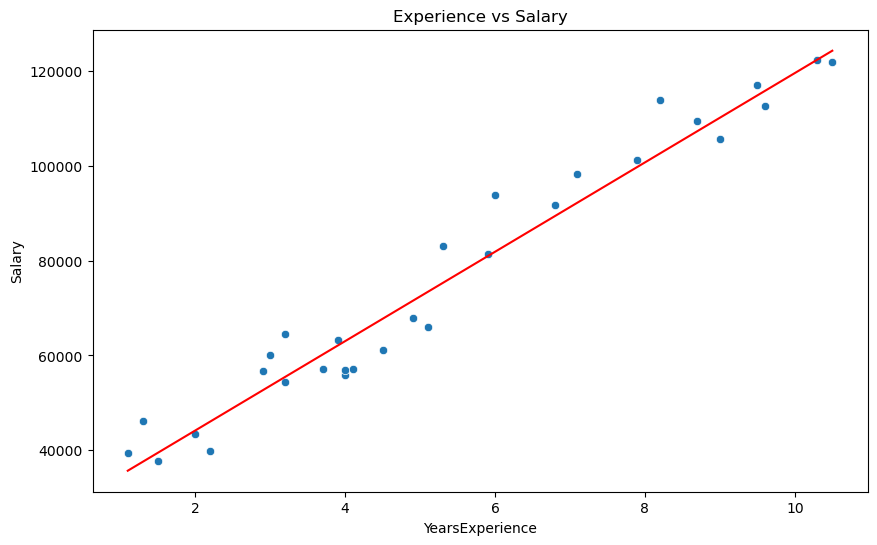

mse: 49830096.85590839
mae: 6286.453830757749
r2_score: 0.9024461774180497
predicted Salary: [[91288.29027299]]
model saved successfully!


In [2]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
#load data
df=pd.read_csv("Salary_Data.csv")
#explore data
df.head()
df.info()
df.describe()
df.isnull().sum()
#select x and y
x=df[["YearsExperience"]]
y=df[["Salary"]]
#split the data set
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
#create a model
model=LinearRegression()
#train model
model.fit(x_train,y_train)
#predict
y_pred=model.predict(x_test)
print(y_pred)
#visualization
plt.figure(figsize=(10,6))
sns.scatterplot(x="YearsExperience",y="Salary",data=df)
plt.plot(df["YearsExperience"],model.predict(x),color="red")
plt.title("Experience vs Salary")
plt.show()
#evaluate
print("mse:",mean_squared_error(y_test,y_pred))
print("mae:",mean_absolute_error(y_test,y_pred))
print("r2_score:",r2_score(y_test,y_pred))
new_data=pd.DataFrame({"YearsExperience":[7]})
salary=model.predict(new_data)
print("predicted Salary:",salary)
joblib.dump(model, "salary_model.pkl")
print("model saved successfully!")